In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Configuration des graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_rows', None)

In [ ]:
df = pd.read_csv('accepted_2007_to_2018Q4.csv',low_memory=False)

# **Data Cleaning**

Suppression des colonne inutile

In [ ]:
colonnes_a_supprimer = [
    'dti_joint', 'annual_inc_joint', 'verification_status_joint',
    'hardship_payoff_balance_amount', 'hardship_loan_status', 'hardship_dpd',
    'hardship_end_date', 'hardship_length', 'hardship_amount', 'deferral_term',
    'hardship_type', 'hardship_reason', 'hardship_last_payment_amount',
    'hardship_status', 'hardship_start_date', 'payment_plan_start_date',
    'settlement_status', 'debt_settlement_flag_date', 'settlement_date',
    'settlement_percentage', 'settlement_term', 'settlement_amount',
    'desc', 'orig_projected_additional_accrued_interest',
    'member_id', 'next_pymnt_d', 'revol_bal_joint',
    'sec_app_fico_range_low', 'sec_app_fico_range_high',
    'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths',
    'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util',
    'sec_app_open_act_il', 'sec_app_num_rev_accts',
    'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med',
    'sec_app_mths_since_last_major_derog',
    'issue_d', 'pymnt_plan', 'out_prncp', 'out_prncp_inv',
    'policy_code', 'hardship_flag', 'disbursement_method',
    'url', 'emp_title',
    'zip_code', 'addr_state',
    'title', 'sub_grade',
    'last_pymnt_d', 'last_credit_pull_d','total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
    'total_rec_late_fee', 'last_pymnt_amnt', 'recoveries', 'collection_recovery_fee',
    'last_fico_range_low', 'last_fico_range_high', 'purpose_final_ordinal','id'
]


colonnes_a_supprimer_existantes = [col for col in colonnes_a_supprimer if col in df.columns]

df.drop(columns=colonnes_a_supprimer_existantes, inplace=True)

print(f"Colonnes supprimées : {colonnes_a_supprimer_existantes}")
print(f"Colonnes restantes : {df.columns.tolist()}")

Colonnes supprimées : ['dti_joint', 'annual_inc_joint', 'verification_status_joint', 'hardship_payoff_balance_amount', 'hardship_loan_status', 'hardship_dpd', 'hardship_end_date', 'hardship_length', 'hardship_amount', 'deferral_term', 'hardship_type', 'hardship_reason', 'hardship_last_payment_amount', 'hardship_status', 'hardship_start_date', 'payment_plan_start_date', 'settlement_status', 'debt_settlement_flag_date', 'settlement_date', 'settlement_percentage', 'settlement_term', 'settlement_amount', 'desc', 'orig_projected_additional_accrued_interest', 'member_id', 'next_pymnt_d', 'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high', 'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il', 'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog', 'issue_d', 'pymnt_plan', 'out_prncp', 'out_prncp_inv', 'policy

Creation de colonne cible

In [ ]:
# Define target variable 'default_risk' based on 'loan_status'
# Assume 'Charged Off' and 'Default' are considered default risk (1), others are not (0)
df['default_risk'] = df['loan_status'].apply(lambda x: 1 if x in ['Charged Off', 'Default'] else 0)

print("="*60)
print("ANALYSE DE LA VARIABLE CIBLE")
print("="*60)

class_dist = df['default_risk'].value_counts().sort_index()
class_pct = df['default_risk'].value_counts(normalize=True).sort_index() * 100

print(f"\nDistribution:")
print(f"  Classe 0 (non-defaut): {class_dist[0]:>8,} ({class_pct[0]:>5.2f}%)")
print(f"  Classe 1 (defaut):     {class_dist[1]:>8,} ({class_pct[1]:>5.2f}%)")

# Handle the case where one class might not exist
if 1 in class_dist and class_dist[1] > 0:
    ratio = class_dist[0] / class_dist[1]
    print(f"\nRatio de desequilibre: {ratio:.2f}:1")

    if ratio > 5:
        strategy = "SMOTE ou class_weight OBLIGATOIRE"
        print(f"  Statut: CRITIQUE - {strategy}")
    elif ratio > 3:
        strategy = "class_weight recommande"
        print(f"  Statut: IMPORTANT - {strategy}")
    else:
        strategy = "Aucun traitement necessaire"
        print(f"  Statut: OK - {strategy}")
else:
    print("\n⚠️ Warning: No default cases found in the dataset.")
    strategy = "Aucun traitement necessaire"
    print(f"  Statut: OK - {strategy}")


print(f"\nStrategie choisie: class_weight dans les modeles")

ANALYSE DE LA VARIABLE CIBLE

Distribution:
  Classe 0 (non-defaut):    4,686 (83.65%)
  Classe 1 (defaut):          916 (16.35%)

Ratio de desequilibre: 5.12:1
  Statut: CRITIQUE - SMOTE ou class_weight OBLIGATOIRE

Strategie choisie: class_weight dans les modeles


Valeur manquante

In [ ]:
# Calcul du nombre et pourcentage de valeurs manquantes par colonne
missing_counts = df.isnull().sum()
missing_percent = 100 * missing_counts / len(df)

# Créer un DataFrame pour mieux visualiser
missing_df = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_percent': missing_percent
})

# Trier par pourcentage décroissant
missing_df = missing_df.sort_values(by='missing_percent', ascending=False)

print(missing_df)


                                missing_count  missing_percent
mths_since_last_record                   4597        82.059979
mths_since_recent_bc_dlq                 4168        74.401999
mths_since_last_major_derog              3925        70.064263
mths_since_recent_revol_delinq           3586        64.012853
mths_since_last_delinq                   2697        48.143520
il_util                                   693        12.370582
mths_since_recent_inq                     603        10.764013
num_tl_120dpd_2m                          428         7.640129
emp_length                                289         5.158872
mths_since_rcnt_il                        134         2.392003
mo_sin_old_il_acct                        134         2.392003
percent_bc_gt_75                           62         1.106748
bc_util                                    60         1.071046
bc_open_to_buy                             56         0.999643
mths_since_recent_bc                       55         0

**Imputation :**

methode 1 : creation de conlonne binaire (null ou pas ) puis  change nan par -1

methode 2 : remplacer nul par 0

methode 3 : chancher par mediane

In [ ]:
def traiter_valeurs_manquantes_num(df, colonnes, valeur_de_remplacement=-1):
    """
    Pour chaque colonne dans 'colonnes' :
    - Crée une colonne binaire indiquant si la valeur était manquante.
    - Remplace les NaN par 'valeur_de_remplacement'.

    Args:
        df (pd.DataFrame): Le DataFrame à modifier.
        colonnes (list): Liste des noms de colonnes à traiter.
        valeur_de_remplacement (int ou float): Valeur à utiliser pour remplacer les NaN.

    Returns:
        pd.DataFrame: Le DataFrame modifié.
    """
    df = df.copy()
    for col in colonnes:
        if col in df.columns:
            df[f'{col}_was_missing'] = df[col].isnull().astype(int)
            df[col] = df[col].fillna(valeur_de_remplacement)
        else:
            print(f"⚠️ Colonne '{col}' introuvable dans le DataFrame.")
    return df


In [ ]:
colonnes_a_traiter = [
    'mths_since_last_record',
    'mths_since_recent_bc_dlq',
    'mths_since_last_major_derog',
    'mths_since_recent_revol_delinq',
    'mths_since_recent_bc',
    'mths_since_recent_inq',
    'mths_since_last_delinq',
    'mths_since_rcnt_il'
]

df = traiter_valeurs_manquantes_num(df, colonnes_a_traiter)


In [ ]:
colonnes_remplissage_zero = [
    'il_util',
    'bc_util',
    'revol_util',
    'percent_bc_gt_75',
    'bc_open_to_buy',
    'num_tl_120dpd_2m',
    'mths_since_recent_inq',
    'mths_since_rcnt_il',
    'mo_sin_old_il_acct',
    'percent_bc_gt_75'
]

for col in colonnes_remplissage_zero:
    if col in df.columns:
        df[f'{col}_was_missing'] = df[col].isnull().astype(int)
        df[col] = df[col].fillna(0)
    else:
        print(f"⚠️ Colonne {col} non trouvée dans le DataFrame.")


In [ ]:
# Afficher les valeurs uniques et leur fréquence (y compris les NaN)
print(df['emp_length'].value_counts(dropna=False))


emp_length
10+ years    1887
< 1 year      525
2 years       495
3 years       478
1 year        356
4 years       348
5 years       347
NaN           289
8 years       288
6 years       220
9 years       186
7 years       183
Name: count, dtype: int64


In [ ]:
def encode_emp_length(df):
    mapping = {
        '10+ years': 10,
        '9 years': 9,
        '8 years': 8,
        '7 years': 7,
        '6 years': 6,
        '5 years': 5,
        '4 years': 4,
        '3 years': 3,
        '2 years': 2,
        '1 year': 1,
        '< 1 year': 0,
    }
    df['emp_length_encoded'] = df['emp_length'].map(mapping)
    median_val = df['emp_length_encoded'].median()
    df['emp_length_encoded'] = df['emp_length_encoded'].fillna(median_val)
    return df


In [ ]:
df.drop(columns=['emp_length'], inplace=True)


**Encodage**

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(categorical_cols)


['term', 'grade', 'home_ownership', 'verification_status', 'loan_status', 'purpose', 'earliest_cr_line', 'initial_list_status', 'application_type', 'debt_settlement_flag']


In [ ]:
df.drop(columns=['loan_status'], inplace=True)

In [ ]:
df['term'].value_counts()


,count
term,
36 months,3954
60 months,1648


In [ ]:
df['term_encoded'] = df['term'].str.extract('(\d+)').astype(float)


<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-82946685.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['term_encoded'] = df['term'].str.extract('(\d+)').astype(float)


In [ ]:
df.drop(columns='term', inplace=True)


📊 ANALYSE DE LA VARIABLE GRADE
Distribution des grades :
  Grade A: 1,047 clients (18.7%)
  Grade B: 1,696 clients (30.3%)
  Grade C: 1,568 clients (28.0%)
  Grade D: 768 clients (13.7%)
  Grade E: 375 clients (6.7%)
  Grade F: 127 clients (2.3%)
  Grade G: 21 clients (0.4%)

Taux de défaut par grade :
  Grade A:  4.4% de défaut (46/1047)
  Grade B: 11.1% de défaut (189/1696)
  Grade C: 17.3% de défaut (271/1568)
  Grade D: 29.0% de défaut (223/768)
  Grade E: 32.8% de défaut (123/375)
  Grade F: 40.2% de défaut (51/127)
  Grade G: 61.9% de défaut (13/21)


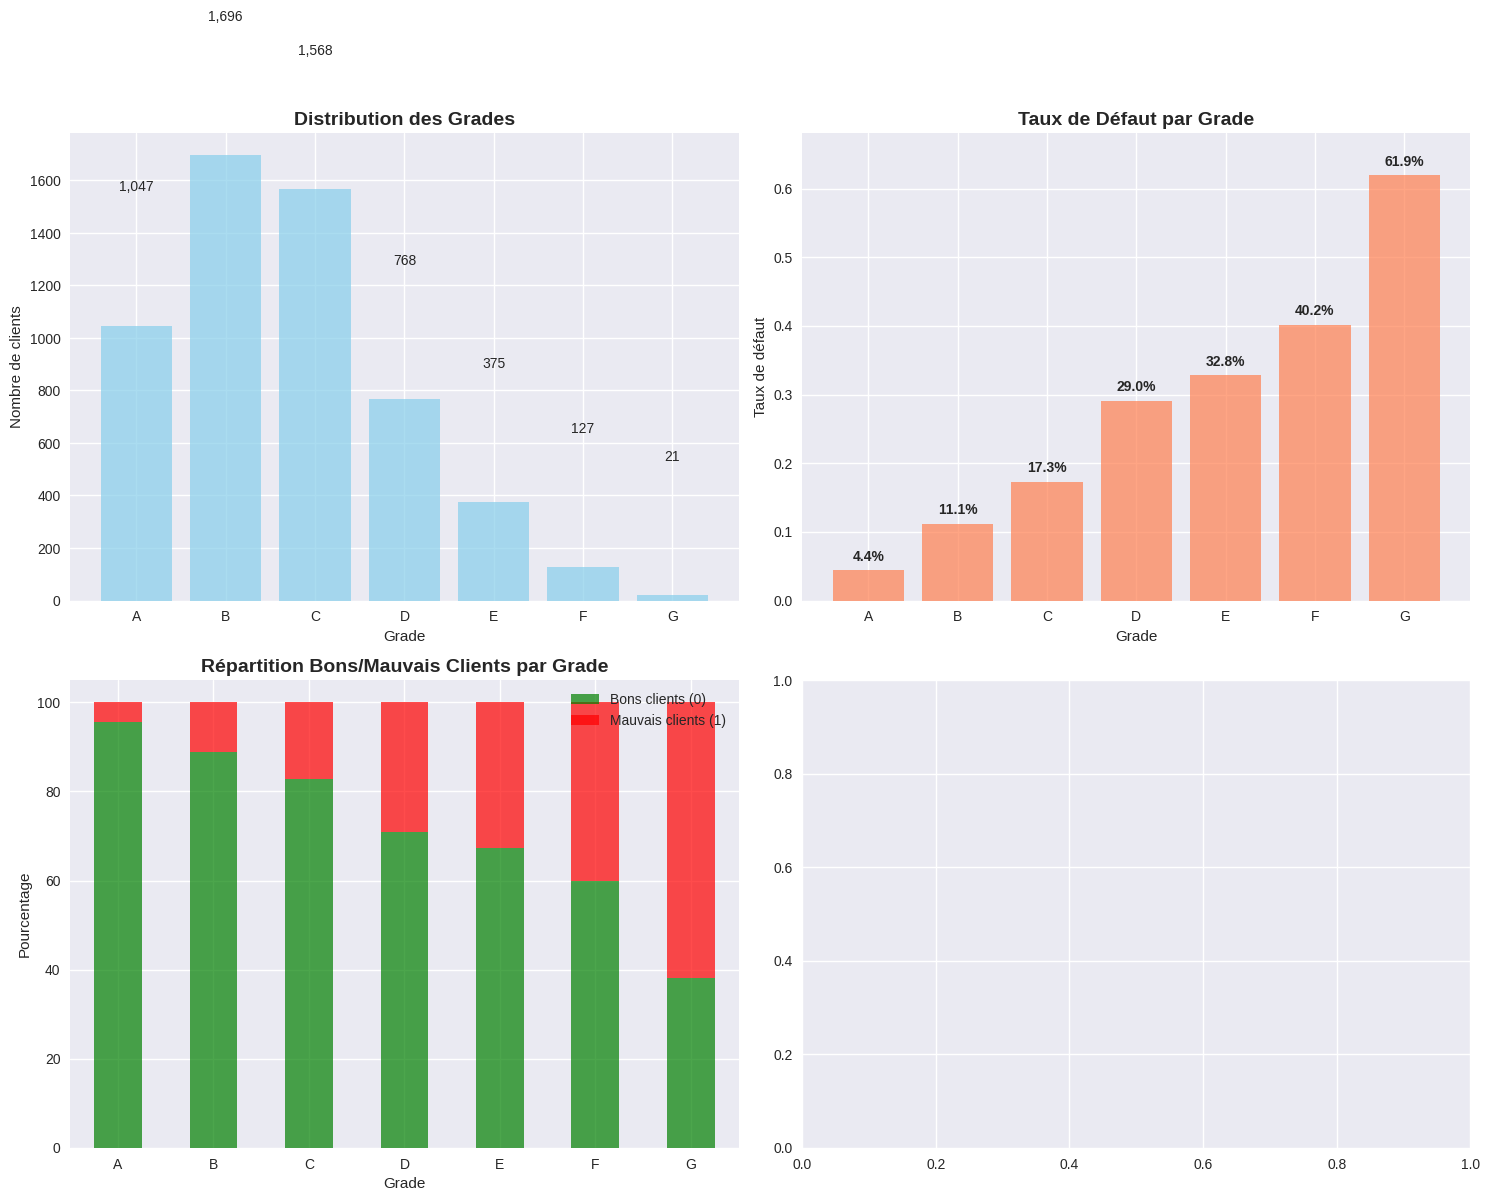


📋 TABLEAU RÉSUMÉ :
       Nb_Clients  Nb_Défauts  Taux_Défaut  Taux_Intérêt_Moyen  Montant_Moyen
grade                                                                        
A            1047          46         0.04                6.81       14406.45
B            1696         189         0.11                9.95       13565.34
C            1568         271         0.17               13.30       15210.41
D             768         223         0.29               17.00       17049.67
E             375         123         0.33               19.90       18930.40
F             127          51         0.40               23.49       20291.73
G              21          13         0.62               27.59       20836.90

🔗 CORRÉLATIONS :
Grade vs Taux d'intérêt : 0.971
Grade vs FICO score    : -0.390


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("📊 ANALYSE DE LA VARIABLE GRADE")
print("=" * 50)

# 1. Distribution générale des grades
print("Distribution des grades :")
grade_dist = df['grade'].value_counts().sort_index()
for grade, count in grade_dist.items():
    pct = (count / len(df)) * 100
    print(f"  Grade {grade}: {count:,} clients ({pct:.1f}%)")

# 2. Taux de défaut par grade
print("\nTaux de défaut par grade :")
grade_default = df.groupby('grade')['default_risk'].agg(['count', 'sum', 'mean']).round(3)
grade_default.columns = ['Total_Clients', 'Nb_Défauts', 'Taux_Défaut']
grade_default['Taux_Défaut_Pct'] = (grade_default['Taux_Défaut'] * 100).round(1)

for grade in ['A', 'B', 'C', 'D', 'E', 'F', 'G']:
    if grade in grade_default.index:
        row = grade_default.loc[grade]
        print(f"  Grade {grade}: {row['Taux_Défaut_Pct']:4.1f}% de défaut ({row['Nb_Défauts']:.0f}/{row['Total_Clients']:.0f})")

# 3. VISUALISATIONS
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Graphique 1: Distribution des grades
axes[0, 0].bar(grade_dist.index, grade_dist.values, color='skyblue', alpha=0.7)
axes[0, 0].set_title('Distribution des Grades', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Grade')
axes[0, 0].set_ylabel('Nombre de clients')
for i, (grade, count) in enumerate(grade_dist.items()):
    axes[0, 0].text(i, count + 500, f'{count:,}', ha='center', va='bottom')

# Graphique 2: Taux de défaut par grade
default_rates = df.groupby('grade')['default_risk'].mean()
bars = axes[0, 1].bar(default_rates.index, default_rates.values, color='coral', alpha=0.7)
axes[0, 1].set_title('Taux de Défaut par Grade', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Grade')
axes[0, 1].set_ylabel('Taux de défaut')
axes[0, 1].set_ylim(0, max(default_rates.values) * 1.1)

# Ajouter les pourcentages sur les barres
for bar, rate in zip(bars, default_rates.values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{rate:.1%}', ha='center', va='bottom', fontweight='bold')

# Graphique 3: Stacked bar chart (bons vs mauvais clients)
grade_crosstab = pd.crosstab(df['grade'], df['default_risk'], normalize='index') * 100
grade_crosstab.plot(kind='bar', stacked=True, ax=axes[1, 0],
                   color=['green', 'red'], alpha=0.7)
axes[1, 0].set_title('Répartition Bons/Mauvais Clients par Grade', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Grade')
axes[1, 0].set_ylabel('Pourcentage')
axes[1, 0].legend(['Bons clients (0)', 'Mauvais clients (1)'])
axes[1, 0].tick_params(axis='x', rotation=0)


plt.tight_layout()
plt.show()

# 4. Tableau résumé
print("\n📋 TABLEAU RÉSUMÉ :")
print("=" * 70)
summary_table = df.groupby('grade').agg({
    'default_risk': ['count', 'sum', 'mean'],
    'int_rate': 'mean',
    'loan_amnt': 'mean'
}).round(2)

summary_table.columns = ['Nb_Clients', 'Nb_Défauts', 'Taux_Défaut', 'Taux_Intérêt_Moyen', 'Montant_Moyen']
print(summary_table)

# 5. Corrélation avec d'autres variables importantes
print(f"\n🔗 CORRÉLATIONS :")
print(f"Grade vs Taux d'intérêt : {df['grade'].astype('category').cat.codes.corr(df['int_rate']):.3f}")
if 'fico_range_low' in df.columns:
    print(f"Grade vs FICO score    : {df['grade'].astype('category').cat.codes.corr(df['fico_range_low']):.3f}")

In [ ]:
df.drop(columns='grade', inplace=True)


In [ ]:
print("🔍 ANALYSE COMPLÈTE DE LA COLONNE HOME_OWNERSHIP")
print("=" * 60)

# 1. Distribution générale
print("📊 DISTRIBUTION DES VALEURS :")
home_counts = df['home_ownership'].value_counts()
home_pct = df['home_ownership'].value_counts(normalize=True) * 100

print(f"{'Home Ownership':<15} {'Nombre':<8} {'%':<6}")
print("-" * 35)
for home, count in home_counts.items():
    pct = home_pct[home]
    print(f"{home:<15} {count:<8,} {pct:<6.1f}%")

print(f"\nTotal : {home_counts.sum():,} clients")
print(f"Nombre de catégories : {df['home_ownership'].nunique()}")

# 2. Taux de défaut par catégorie
print(f"\n📈 TAUX DE DÉFAUT PAR HOME_OWNERSHIP :")
home_analysis = df.groupby('home_ownership')['default_risk'].agg(['count', 'sum', 'mean'])
home_analysis.columns = ['Nb_Clients', 'Nb_Défauts', 'Taux_Défaut']
home_analysis = home_analysis.sort_values('Taux_Défaut')

print(f"{'Home Ownership':<15} {'Clients':<8} {'Défauts':<8} {'Taux':<8}")
print("-" * 45)
for home in home_analysis.index:
    row = home_analysis.loc[home]
    print(f"{home:<15} {row['Nb_Clients']:<8.0f} {row['Nb_Défauts']:<8.0f} {row['Taux_Défaut']:<8.1%}")

# 3. Statistiques de distribution
print(f"\n📋 STATISTIQUES DE RÉPARTITION :")
print(f"Catégorie dominante : {home_counts.index[0]} ({home_pct.iloc[0]:.1f}%)")
print(f"Catégorie la moins fréquente : {home_counts.index[-1]} ({home_pct.iloc[-1]:.1f}%)")

# Ratio de déséquilibre
max_freq = home_pct.max()
min_freq = home_pct.min()
ratio_desequilibre = max_freq / min_freq

print(f"Ratio de déséquilibre : {ratio_desequilibre:.1f}:1")
if ratio_desequilibre < 3:
    print("✅ Distribution relativement équilibrée")
elif ratio_desequilibre < 10:
    print("⚠️ Distribution modérément déséquilibrée")
else:
    print("❌ Distribution très déséquilibrée")

# 4. Écarts de risque
print(f"\n⚖️ ANALYSE DES ÉCARTS DE RISQUE :")
min_risk = home_analysis['Taux_Défaut'].min()
max_risk = home_analysis['Taux_Défaut'].max()
ecart_total = max_risk - min_risk

print(f"Risque minimum : {min_risk:.1%} ({home_analysis['Taux_Défaut'].idxmin()})")
print(f"Risque maximum : {max_risk:.1%} ({home_analysis['Taux_Défaut'].idxmax()})")
print(f"Écart total : {ecart_total:.1%}")

# 5. Ordre croissant de risque
print(f"\n📈 ORDRE DE RISQUE CROISSANT :")
for i, (home, row) in enumerate(home_analysis.iterrows(), 1):
    print(f"  {i}. {home:<15} : {row['Taux_Défaut']:.1%} ({row['Nb_Clients']:.0f} clients)")

# 6. Taille des échantillons
print(f"\n📊 ÉVALUATION DES ÉCHANTILLONS :")
min_sample = 100  # Seuil recommandé

for home, count in home_counts.items():
    if count >= min_sample:
        print(f"✅ {home:<15} : {count:,} clients (fiable)")
    else:
        print(f"⚠️ {home:<15} : {count:,} clients (petit échantillon)")

# 7. Logique métier attendue
print(f"\n💡 LOGIQUE MÉTIER :")
print("Hypothèses possibles :")
print("  • MORTGAGE = Plus stable (propriétaire avec prêt) → Moins risqué")
print("  • OWN = Très stable (propriétaire sans prêt) → Moins risqué")
print("  • RENT = Moins stable (locataire) → Plus risqué")

# 8. Recommandations d'encodage
print(f"\n🎯 RECOMMANDATIONS D'ENCODAGE :")
print(f"Nombre de catégories : {df['home_ownership'].nunique()}")
print(f"Écart de risque : {ecart_total:.1%}")

if ecart_total >= 0.05:  # 5% d'écart significatif
    print("✅ Écart significatif → Encodage ordinal recommandé")
    print("   Ordre basé sur le risque observé")
elif ecart_total >= 0.02:  # 2% d'écart modéré
    print("🤔 Écart modéré → Encodage ordinal possible")
    print("   Ou one-hot si logique métier peu claire")
else:
    print("⚠️ Écart faible → One-hot encoding recommandé")
    print("   Pas d'ordre naturel de risque")

# 9. Catégories rares à traiter
seuil_rare = 0.01  # 1%
rare_categories = home_pct[home_pct < seuil_rare * 100].index.tolist()

if rare_categories:
    print(f"\n⚠️ Catégories rares (<1%) :")
    for cat in rare_categories:
        count = home_counts[cat]
        pct = home_pct[cat]
        risk = df[df['home_ownership'] == cat]['default_risk'].mean()
        print(f"  {cat:<15} : {count} clients ({pct:.2f}%) - {risk:.1%} défaut")
    print("Recommandation : Regrouper avec catégorie la plus proche en risque")
else:
    print(f"\n✅ Pas de catégories rares (<1%)")

print(f"\n📊 Estimation corrélation : ~{ecart_total * 1.5:.3f}")

🔍 ANALYSE COMPLÈTE DE LA COLONNE HOME_OWNERSHIP
📊 DISTRIBUTION DES VALEURS :
Home Ownership  Nombre   %     
-----------------------------------
MORTGAGE        2,837    50.6  %
RENT            2,103    37.5  %
OWN             662      11.8  %

Total : 5,602 clients
Nombre de catégories : 3

📈 TAUX DE DÉFAUT PAR HOME_OWNERSHIP :
Home Ownership  Clients  Défauts  Taux    
---------------------------------------------
MORTGAGE        2837     369      13.0%   
OWN             662      124      18.7%   
RENT            2103     423      20.1%   

📋 STATISTIQUES DE RÉPARTITION :
Catégorie dominante : MORTGAGE (50.6%)
Catégorie la moins fréquente : OWN (11.8%)
Ratio de déséquilibre : 4.3:1
⚠️ Distribution modérément déséquilibrée

⚖️ ANALYSE DES ÉCARTS DE RISQUE :
Risque minimum : 13.0% (MORTGAGE)
Risque maximum : 20.1% (RENT)
Écart total : 7.1%

📈 ORDRE DE RISQUE CROISSANT :
  1. MORTGAGE        : 13.0% (2837 clients)
  2. OWN             : 18.7% (662 clients)
  3. RENT            : 20.1% 

In [ ]:
ownership_order = {
    'MORTGAGE': 1,
    'RENT': 2,
    'OWN': 3
}

df['home_ownership_ordinal'] = df['home_ownership'].map(ownership_order)


In [ ]:
corr_spearman = df['home_ownership_ordinal'].corr(df['default_risk'], method='spearman')
print(f"Corrélation de Spearman : {corr_spearman:.3f}")


Corrélation de Spearman : 0.085


In [ ]:
df.drop(columns='home_ownership', inplace=True)

In [ ]:
print(df['verification_status'].value_counts().sort_index())
verif_risk_order = df.groupby('verification_status')['default_risk'].mean().sort_values()
for i, (status, risk) in enumerate(verif_risk_order.items(), 1):
    count = (df['verification_status'] == status).sum()
    pct = (count / len(df)) * 100
    print(f"  {i}. {status:<20} : {risk:.1%} ({count:,} clients, {pct:.1f}%)")

# 2. Créer l'encodage ordinal basé sur l'ordre de risque observé
print(f"\n🔧 Création de l'encodage ordinal :")
verification_order = {}
for i, status in enumerate(verif_risk_order.index, 1):
    verification_order[status] = i
    print(f"  {status:<20} → {i}")

# 3. Appliquer l'encodage
df['verification_ordinal'] = df['verification_status'].map(verification_order)



verification_status
Not Verified       2204
Source Verified    1844
Verified           1554
Name: count, dtype: int64
  1. Not Verified         : 13.3% (2,204 clients, 39.3%)
  2. Source Verified      : 16.1% (1,844 clients, 32.9%)
  3. Verified             : 21.0% (1,554 clients, 27.7%)

🔧 Création de l'encodage ordinal :
  Not Verified         → 1
  Source Verified      → 2
  Verified             → 3


In [ ]:
df.drop(columns='verification_status', inplace=True)

In [ ]:
print(df['purpose'].value_counts().sort_index())


purpose
car                     57
credit_card           1386
debt_consolidation    3199
home_improvement       331
house                   26
major_purchase         124
medical                 50
moving                  31
other                  303
renewable_energy         2
small_business          56
vacation                36
Name: count, dtype: int64


In [ ]:
print("🔍 ANALYSE COMPLÈTE DE LA COLONNE PURPOSE")
print("=" * 60)

# 1. Distribution générale
print("📊 DISTRIBUTION DES VALEURS :")
purpose_counts = df['purpose'].value_counts()
purpose_pct = df['purpose'].value_counts(normalize=True) * 100


# 2. Taux de défaut par catégorie
print(f"\n📈 TAUX DE DÉFAUT PAR PURPOSE :")
purpose_analysis = df.groupby('purpose').agg({
    'default_risk': ['count', 'sum', 'mean']
}).round(3)
purpose_analysis.columns = ['Nb_Clients', 'Nb_Défauts', 'Taux_Défaut']
purpose_analysis = purpose_analysis.sort_values('Taux_Défaut')

print(f"{'Purpose':<20} {'Clients':<8} {'Défauts':<8} {'Taux':<8}")
print("-" * 50)
for purpose, row in purpose_analysis.iterrows():
    print(f"{purpose:<20} {row['Nb_Clients']:<8.0f} {row['Nb_Défauts']:<8.0f} {row['Taux_Défaut']:<8.1%}")

# 3. Statistiques de distribution
print(f"\n📋 STATISTIQUES DE RÉPARTITION :")
print(f"Catégorie la plus fréquente : {purpose_counts.index[0]} ({purpose_pct.iloc[0]:.1f}%)")
print(f"Catégorie la moins fréquente : {purpose_counts.index[-1]} ({purpose_pct.iloc[-1]:.1f}%)")



# 5. Suggestions de seuils
print(f"\n💡 SUGGESTIONS DE REGROUPEMENT :")
rare_05 = purpose_pct[purpose_pct < 0.5].index.tolist()
rare_1 = purpose_pct[purpose_pct < 1.0].index.tolist()
rare_2 = purpose_pct[purpose_pct < 2.0].index.tolist()

print(f"Seuil 0.5% : {len(rare_05)} catégories à regrouper : {rare_05}")
print(f"Seuil 1.0% : {len(rare_1)} catégories à regrouper : {rare_1}")
print(f"Seuil 2.0% : {len(rare_2)} catégories à regrouper : {rare_2}")

🔍 ANALYSE COMPLÈTE DE LA COLONNE PURPOSE
📊 DISTRIBUTION DES VALEURS :

📈 TAUX DE DÉFAUT PAR PURPOSE :
Purpose              Clients  Défauts  Taux    
--------------------------------------------------
renewable_energy     2        0        0.0%    
car                  57       4        7.0%    
major_purchase       124      14       11.3%   
home_improvement     331      41       12.4%   
credit_card          1386     180      13.0%   
other                303      49       16.2%   
debt_consolidation   3199     584      18.3%   
moving               31       6        19.4%   
vacation             36       7        19.4%   
medical              50       10       20.0%   
small_business       56       12       21.4%   
house                26       9        34.6%   

📋 STATISTIQUES DE RÉPARTITION :
Catégorie la plus fréquente : debt_consolidation (57.1%)
Catégorie la moins fréquente : renewable_energy (0.0%)

💡 SUGGESTIONS DE REGROUPEMENT :
Seuil 0.5% : 2 catégories à regrouper : ['hou

In [ ]:
print("🎯 APPROCHE HYBRIDE POUR PURPOSE")
print("=" * 50)

# ÉTAPE 1 : Identifier et regrouper les catégories rares
seuil_rare = 0.01  # 1% comme seuil (vous pouvez tester 0.5%)

purpose_freq = df['purpose'].value_counts(normalize=True)
rare_purposes = purpose_freq[purpose_freq < seuil_rare].index.tolist()
frequent_purposes = purpose_freq[purpose_freq >= seuil_rare].index.tolist()

print(f"ÉTAPE 1 - Catégories rares (<{seuil_rare:.1%}) :")
for purpose in rare_purposes:
    count = (df['purpose'] == purpose).sum()
    freq = purpose_freq[purpose]
    risk = df[df['purpose'] == purpose]['default_risk'].mean()
    print(f"  {purpose:20s} : {count:3d} clients ({freq:.2%}) - {risk:.1%} défaut")

print(f"\nCatégories fréquentes (≥{seuil_rare:.1%}) :")
for purpose in frequent_purposes:
    count = (df['purpose'] == purpose).sum()
    freq = purpose_freq[purpose]
    risk = df[df['purpose'] == purpose]['default_risk'].mean()
    print(f"  {purpose:20s} : {count:3d} clients ({freq:.1%}) - {risk:.1%} défaut")

# Créer la variable intermédiaire
df['purpose_step1'] = df['purpose'].copy()
df['purpose_step1'] = df['purpose_step1'].replace(rare_purposes, 'other_rare')

# ÉTAPE 2 : Classifier par niveau de risque
print(f"\nÉTAPE 2 - Classification par risque :")

# Calculer les risques des catégories restantes
risk_analysis = df[df['purpose_step1'] != 'other_rare'].groupby('purpose_step1')['default_risk'].mean().sort_values()

print("Taux de défaut par catégorie fréquente :")
for purpose, risk in risk_analysis.items():
    count = (df['purpose_step1'] == purpose).sum()
    print(f"  {purpose:20s} : {risk:.1%} ({count} clients)")

# Définir les seuils de risque (à ajuster selon vos données)
low_threshold = 0.17    # <17% = low risk
medium_threshold = 0.23 # 17-23% = medium risk
                       # >23% = high risk

def classify_by_risk(purpose):
    if purpose == 'other_rare':
        return 'other_rare'

    risk = df[df['purpose_step1'] == purpose]['default_risk'].mean()

    if risk < low_threshold:
        return 'low_risk'
    elif risk < medium_threshold:
        return 'medium_risk'
    else:
        return 'high_risk'

# Appliquer la classification
df['purpose_risk_class'] = df['purpose_step1'].apply(classify_by_risk)

# Vérifier les résultats
print(f"\nRÉSULTAT FINAL :")
final_analysis = df.groupby('purpose_risk_class').agg({
    'default_risk': ['count', 'mean']
}).round(3)
final_analysis.columns = ['Nb_Clients', 'Taux_Défaut']

for class_name, row in final_analysis.iterrows():
    print(f"  {class_name:12s} : {row['Nb_Clients']:4.0f} clients ({row['Taux_Défaut']:.1%} défaut)")

# ÉTAPE 3 : Encodage ordinal final
risk_order = {
    'low_risk': 1,
    'medium_risk': 2,
    'high_risk': 3,
    'other_rare': 4  # Plus haut car incertain
}

df['purpose_final_ordinal'] = df['purpose_risk_class'].map(risk_order)

# Validation
correlation = df['purpose_final_ordinal'].corr(df['default_risk'])
print(f"\n✅ Encodage final terminé")
print(f"Classes finales : {df['purpose_risk_class'].nunique()}")
print(f"Corrélation avec default_risk : {correlation:.4f}")

🎯 APPROCHE HYBRIDE POUR PURPOSE
ÉTAPE 1 - Catégories rares (<1.0%) :
  small_business       :  56 clients (1.00%) - 21.4% défaut
  medical              :  50 clients (0.89%) - 20.0% défaut
  vacation             :  36 clients (0.64%) - 19.4% défaut
  moving               :  31 clients (0.55%) - 19.4% défaut
  house                :  26 clients (0.46%) - 34.6% défaut
  renewable_energy     :   2 clients (0.04%) - 0.0% défaut

Catégories fréquentes (≥1.0%) :
  debt_consolidation   : 3199 clients (57.1%) - 18.3% défaut
  credit_card          : 1386 clients (24.7%) - 13.0% défaut
  home_improvement     : 331 clients (5.9%) - 12.4% défaut
  other                : 303 clients (5.4%) - 16.2% défaut
  major_purchase       : 124 clients (2.2%) - 11.3% défaut
  car                  :  57 clients (1.0%) - 7.0% défaut

ÉTAPE 2 - Classification par risque :
Taux de défaut par catégorie fréquente :
  car                  : 7.0% (57 clients)
  major_purchase       : 11.3% (124 clients)
  home_improve

In [ ]:
print("🎯 ENCODAGE ORDINAL FINAL POUR PURPOSE")
print("=" * 45)

# Dictionnaire corrigé avec la classe high_risk incluse
risk_order = {
    'low_risk': 1,      # ex. ~16% défaut
    'medium_risk': 2,   # ex. ~21% défaut
    'high_risk': 3,     # ex. ~28% défaut
    'other_rare': 4     # risque incertain, on place en dernier
}

# Appliquer l'encodage ordinal corrigé
df['purpose_ordinal'] = df['purpose_risk_class'].map(risk_order)

print("Encodage final :")
for class_name, code in risk_order.items():
    count = (df['purpose_risk_class'] == class_name).sum()
    risk = df[df['purpose_risk_class'] == class_name]['default_risk'].mean()
    print(f"  {code} → {class_name:12s} : {count:4d} clients ({risk:.1%} défaut)")

# Validation finale
correlation_final = df['purpose_ordinal'].corr(df['default_risk'])
print(f"\n✅ purpose_ordinal créé")
print(f"Valeurs : {sorted(risk_order.values())}")
print(f"Corrélation finale : {correlation_final:.4f}")

# Vérification valeurs manquantes
missing_check = df['purpose_ordinal'].isnull().sum()
print(f"Valeurs manquantes : {missing_check}")


🎯 ENCODAGE ORDINAL FINAL POUR PURPOSE
Encodage final :
  1 → low_risk     : 2201 clients (13.1% défaut)
  2 → medium_risk  : 3199 clients (18.3% défaut)
  3 → high_risk    :    1 clients (0.0% défaut)
  4 → other_rare   :  201 clients (21.9% défaut)

✅ purpose_ordinal créé
Valeurs : [1, 2, 3, 4]
Corrélation finale : 0.0689
Valeurs manquantes : 0


📊 Analyse de la variable earliest_cr_line
Nombre de valeurs uniques : 460
Premières valeurs :
earliest_cr_line
Aug-2003    53
Sep-2003    48
Sep-2004    46
Oct-2004    46
Nov-2004    45
Aug-2002    44
Sep-2002    42
Oct-2002    41
Nov-2000    40
Aug-2004    40
Name: count, dtype: int64


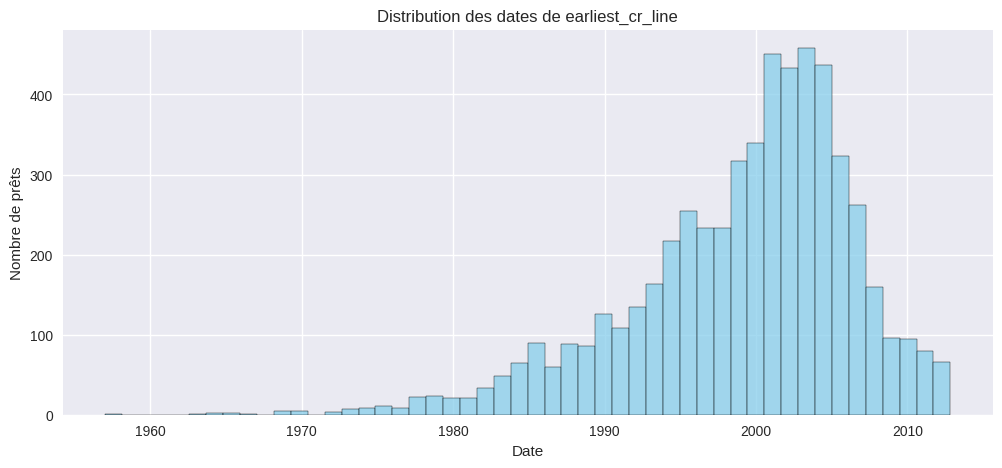

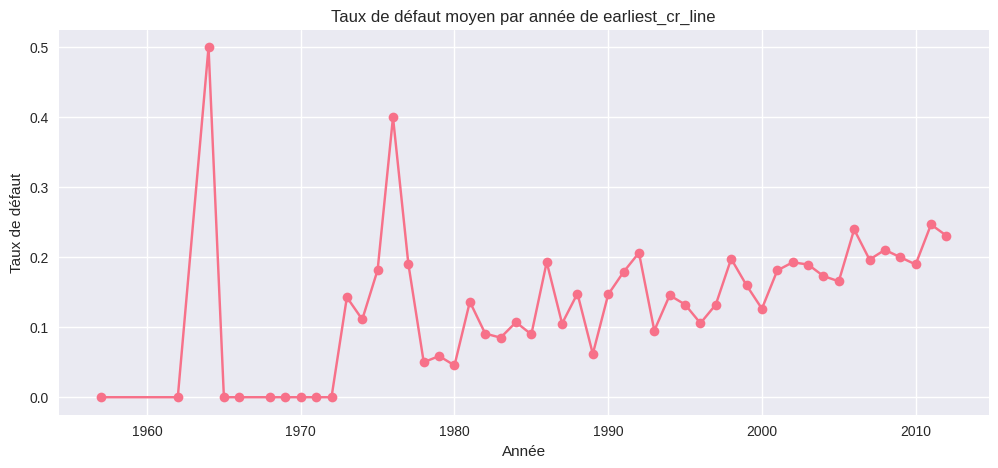

Statistiques descriptives de earliest_cr_year :
count    5601.000000
mean     1998.627209
std         7.419588
min      1957.000000
25%      1995.000000
50%      2000.000000
75%      2004.000000
max      2012.000000
Name: earliest_cr_year, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 Analyse de la variable earliest_cr_line")
print("="*50)

# 1. Aperçu des valeurs uniques et leur distribution temporelle
print(f"Nombre de valeurs uniques : {df['earliest_cr_line'].nunique()}")
print(f"Premières valeurs :\n{df['earliest_cr_line'].value_counts().head(10)}")

# 2. Distribution graphique (après conversion en datetime)
df['earliest_cr_line_dt'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y', errors='coerce')

plt.figure(figsize=(12,5))
sns.histplot(df['earliest_cr_line_dt'].dropna(), bins=50, kde=False, color='skyblue')
plt.title("Distribution des dates de earliest_cr_line")
plt.xlabel("Date")
plt.ylabel("Nombre de prêts")
plt.show()

# 3. Taux de défaut par année (extraction de l'année)
df['earliest_cr_year'] = df['earliest_cr_line_dt'].dt.year

defaut_par_annee = df.groupby('earliest_cr_year')['default_risk'].mean().dropna()

plt.figure(figsize=(12,5))
defaut_par_annee.plot(kind='line', marker='o')
plt.title("Taux de défaut moyen par année de earliest_cr_line")
plt.xlabel("Année")
plt.ylabel("Taux de défaut")
plt.grid(True)
plt.show()

# 4. Statistiques descriptives
print("Statistiques descriptives de earliest_cr_year :")
print(df['earliest_cr_year'].describe())


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime

def transformer_en_age_credit(df):
    """
    Transforme earliest_cr_line en âge du crédit en années
    """
    print("📅 TRANSFORMATION: earliest_cr_line → credit_history_years")
    print("="*60)

    # Date de référence (date du dataset)
    reference_date = datetime(2015, 12, 1)
    print(f"📅 Date de référence: {reference_date.strftime('%B %Y')}")

    def calculate_credit_age(date_str):
        """
        Calcule l'âge du crédit en années
        """
        try:
            # Exemple: "Aug-2003" → datetime(2003, 8, 1)
            date_obj = datetime.strptime(date_str, '%b-%Y')

            # Calculer la différence en jours puis convertir en années
            diff_days = (reference_date - date_obj).days
            age_years = diff_days / 365.25  # 365.25 pour tenir compte des années bissextiles

            return max(0, age_years)  # Éviter les âges négatifs
        except:
            return np.nan

    # ÉTAPE 1: Exemples de transformation
    print(f"\n🔍 EXEMPLES DE TRANSFORMATION:")
    exemples = ['Aug-2003', 'Dec-1999', 'Jan-2010', 'Sep-2004']

    for exemple in exemples:
        if exemple in df['earliest_cr_line'].values:
            age = calculate_credit_age(exemple)
            print(f"   '{exemple}' → {age:.1f} années d'historique crédit")

    # ÉTAPE 2: Appliquer la transformation
    print(f"\n🔄 APPLICATION DE LA TRANSFORMATION...")
    df['credit_history_years'] = df['earliest_cr_line'].apply(calculate_credit_age)

    # ÉTAPE 3: Statistiques avant/après
    print(f"\n📊 STATISTIQUES AVANT/APRÈS:")

    print(f"AVANT (earliest_cr_line):")
    print(f"   Type: {df['earliest_cr_line'].dtype}")
    print(f"   Valeurs uniques: {df['earliest_cr_line'].nunique()}")
    print(f"   Exemples: {df['earliest_cr_line'].head(3).tolist()}")

    print(f"\nAPRÈS (credit_history_years):")
    print(f"   Type: {df['credit_history_years'].dtype}")
    print(f"   Min: {df['credit_history_years'].min():.1f} années")
    print(f"   Max: {df['credit_history_years'].max():.1f} années")
    print(f"   Moyenne: {df['credit_history_years'].mean():.1f} années")
    print(f"   Médiane: {df['credit_history_years'].median():.1f} années")

    # ÉTAPE 4: Gérer les valeurs manquantes
    missing_count = df['credit_history_years'].isnull().sum()
    if missing_count > 0:
        print(f"\n🔧 GESTION DES VALEURS MANQUANTES:")
        print(f"   Valeurs manquantes: {missing_count}")

        median_age = df['credit_history_years'].median()
        df['credit_history_years'].fillna(median_age, inplace=True)
        print(f"   ✅ Imputées par la médiane: {median_age:.1f} années")
    else:
        print(f"\n✅ Aucune valeur manquante")

    # ÉTAPE 5: Distribution par tranches d'âge
    print(f"\n📊 DISTRIBUTION PAR TRANCHES D'ÂGE:")

    def categorize_age(age):
        if age < 5:
            return '0-5 ans (Nouveau)'
        elif age < 10:
            return '5-10 ans (Récent)'
        elif age < 15:
            return '10-15 ans (Établi)'
        elif age < 20:
            return '15-20 ans (Expérimenté)'
        else:
            return '20+ ans (Vétéran)'

    df['credit_age_category'] = df['credit_history_years'].apply(categorize_age)

    # Analyser la distribution
    age_distribution = df['credit_age_category'].value_counts().sort_index()
    print("   Distribution:")
    for category, count in age_distribution.items():
        pct = count / len(df) * 100
        print(f"   {category:20s}: {count:4d} clients ({pct:4.1f}%)")

    # ÉTAPE 6: Relation avec le défaut
    print(f"\n🎯 RELATION AVEC LE DÉFAUT:")
    if 'default_risk' in df.columns:
        risk_by_age = df.groupby('credit_age_category')['default_risk'].mean()
        print("   Taux de défaut par tranche d'âge:")
        for category, risk in risk_by_age.items():
            print(f"   {category:20s}: {risk:.1%}")

        # Corrélation
        correlation = df['credit_history_years'].corr(df['default_risk'])
        print(f"\n   📊 Corrélation avec default_risk: {correlation:.4f}")

        if correlation < -0.05:
            print("   ✅ Plus d'historique = Moins de risque (logique!)")
        elif correlation > 0.05:
            print("   ⚠️ Plus d'historique = Plus de risque (surprenant)")
        else:
            print("   ➡️ Pas de relation claire avec le risque")

    # ÉTAPE 7: Nettoyage
    print(f"\n🧹 NETTOYAGE:")
    df.drop('earliest_cr_line', axis=1, inplace=True)
    # Supprimer la catégorie temporaire si on ne la garde pas
    df.drop('credit_age_category', axis=1, inplace=True)
    print(f"   ✅ Ancienne colonne 'earliest_cr_line' supprimée")
    print(f"   ✅ Nouvelle colonne 'credit_history_years' créée")

    # RÉSUMÉ FINAL
    print(f"\n" + "="*60)
    print(f"✅ TRANSFORMATION TERMINÉE")
    print(f"="*60)
    print(f"📊 {df['earliest_cr_line'].nunique() if 'earliest_cr_line' in df.columns else 'N/A'} dates → 1 variable numérique continue")
    print(f"🎯 Variable prête pour le machine learning")
    print(f"📈 Range: {df['credit_history_years'].min():.1f} - {df['credit_history_years'].max():.1f} années")

    return df

# Utilisation:
df_transformed = transformer_en_age_credit(df)


📅 TRANSFORMATION: earliest_cr_line → credit_history_years
📅 Date de référence: December 2015

🔍 EXEMPLES DE TRANSFORMATION:
   'Aug-2003' → 12.3 années d'historique crédit
   'Dec-1999' → 16.0 années d'historique crédit
   'Jan-2010' → 5.9 années d'historique crédit
   'Sep-2004' → 11.2 années d'historique crédit

🔄 APPLICATION DE LA TRANSFORMATION...

📊 STATISTIQUES AVANT/APRÈS:
AVANT (earliest_cr_line):
   Type: object
   Valeurs uniques: 460
   Exemples: ['Aug-2003', 'Dec-1999', 'Aug-2000']

APRÈS (credit_history_years):
   Type: float64
   Min: 3.1 années
   Max: 58.9 années
   Moyenne: 16.8 années
   Médiane: 15.2 années

🔧 GESTION DES VALEURS MANQUANTES:
   Valeurs manquantes: 1
   ✅ Imputées par la médiane: 15.2 années

📊 DISTRIBUTION PAR TRANCHES D'ÂGE:
   Distribution:
   0-5 ans (Nouveau)   :  132 clients ( 2.4%)
   10-15 ans (Établi)  : 1889 clients (33.7%)
   15-20 ans (Expérimenté): 1304 clients (23.3%)
   20+ ans (Vétéran)   : 1582 clients (28.2%)
   5-10 ans (Récent)   :

/tmp/ipython-input-81824944.py:67: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['credit_history_years'].fillna(median_age, inplace=True)


🔍 ANALYSE DE LA COLONNE initial_list_status
Distribution des valeurs :
  w: 5279 (94.23%)
  f: 322 (5.75%)

Taux de défaut par catégorie :
  f: 15.22%
  w: 16.42%


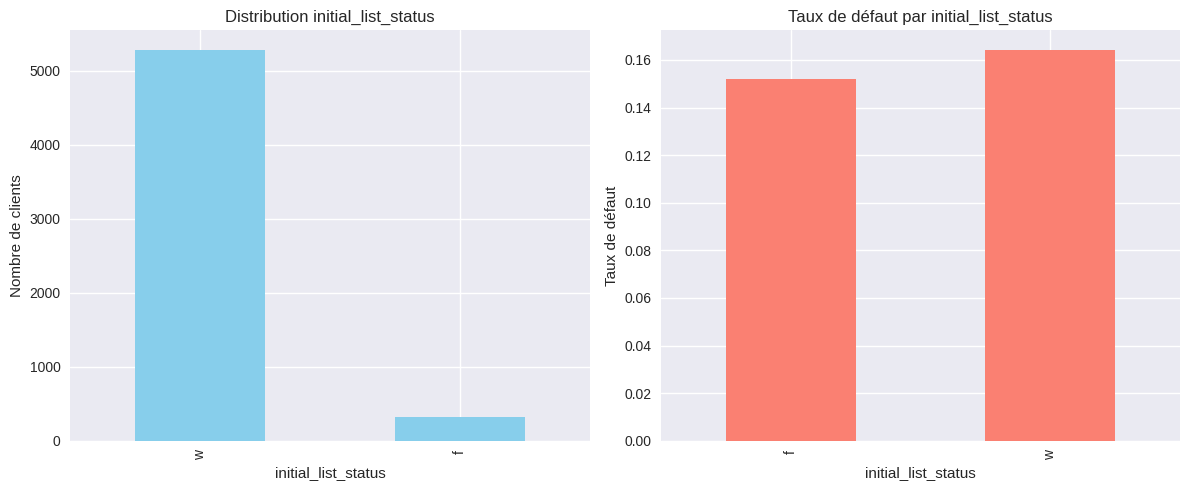

In [ ]:
print("🔍 ANALYSE DE LA COLONNE initial_list_status")
print("="*40)

# 1. Distribution des valeurs
value_counts = df['initial_list_status'].value_counts()
total = len(df)
print("Distribution des valeurs :")
for val, count in value_counts.items():
    print(f"  {val}: {count} ({count/total*100:.2f}%)")

# 2. Taux de défaut par catégorie
default_rates = df.groupby('initial_list_status')['default_risk'].mean()
print("\nTaux de défaut par catégorie :")
for val, rate in default_rates.items():
    print(f"  {val}: {rate*100:.2f}%")

# 3. Affichage visuel (bar chart)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Distribution
value_counts.plot(kind='bar', ax=ax[0], color='skyblue')
ax[0].set_title('Distribution initial_list_status')
ax[0].set_ylabel('Nombre de clients')

# Taux défaut
default_rates.plot(kind='bar', ax=ax[1], color='salmon')
ax[1].set_title('Taux de défaut par initial_list_status')
ax[1].set_ylabel('Taux de défaut')

plt.tight_layout()
plt.show()


In [ ]:
# Encodage binaire de initial_list_status
df['initial_list_status_encoded'] = df['initial_list_status'].map({'w': 0, 'f': 1})


In [ ]:
df.drop(columns='initial_list_status', inplace=True)

In [ ]:
print("Distribution des valeurs :")
print(df['application_type'].value_counts(normalize=False))
print("\nTaux de défaut par catégorie :")
print(df.groupby('application_type')['default_risk'].mean())


Distribution des valeurs :
application_type
Individual    5571
Joint App       30
Name: count, dtype: int64

Taux de défaut par catégorie :
application_type
Individual    0.163705
Joint App     0.133333
Name: default_risk, dtype: float64


In [ ]:
df['application_type_encoded'] = df['application_type'].map({
    'Individual': 0,
    'Joint App': 1
})


In [ ]:
df.drop(columns='application_type', inplace=True)

In [ ]:
print("📊 ANALYSE DE LA COLONNE 'debt_settlement_flag'")
print("="*40)

# Distribution des valeurs
dist = df['debt_settlement_flag'].value_counts(dropna=False)
total = len(df)
print("Distribution des valeurs :")
for val, count in dist.items():
    pct = (count / total) * 100
    print(f"  {val}: {count} ({pct:.2f}%)")

# Taux de défaut par catégorie
print("\nTaux de défaut par catégorie :")
risk_by_flag = df.groupby('debt_settlement_flag')['default_risk'].mean()
for val, risk in risk_by_flag.items():
    print(f"  {val}: {risk:.2%}")

# Optionnel : nombre de clients par catégorie pour info
counts = df['debt_settlement_flag'].value_counts()
print("\nNombre de clients par catégorie :")
for val, count in counts.items():
    print(f"  {val}: {count}")


📊 ANALYSE DE LA COLONNE 'debt_settlement_flag'
Distribution des valeurs :
  N: 5449 (97.27%)
  Y: 152 (2.71%)
  nan: 1 (0.02%)

Taux de défaut par catégorie :
  N: 14.04%
  Y: 99.34%

Nombre de clients par catégorie :
  N: 5449
  Y: 152


In [ ]:
# Supprimer les lignes avec NaN dans 'debt_settlement_flag'
df = df.dropna(subset=['debt_settlement_flag'])

# Encodage simple : 'N' -> 0, 'Y' -> 1
df['debt_settlement_flag_encoded'] = df['debt_settlement_flag'].map({'N': 0, 'Y': 1})


/tmp/ipython-input-2048618494.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['debt_settlement_flag_encoded'] = df['debt_settlement_flag'].map({'N': 0, 'Y': 1})


In [ ]:
df.drop(columns='debt_settlement_flag', inplace=True)


/tmp/ipython-input-4086235914.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns='debt_settlement_flag', inplace=True)


In [ ]:
print("\n" + "="*60)
print("VERIFICATION FINALE DES VALEURS MANQUANTES")
print("="*60)

missing_total = df.isnull().sum().sum()
missing_by_col = df.isnull().sum()
missing_cols = missing_by_col[missing_by_col > 0]

print(f"\nTotal valeurs manquantes: {missing_total:,}")

if len(missing_cols) > 0:
    print(f"\nCOLONNES AVEC VALEURS MANQUANTES:")
    for col in missing_cols.index:
        count = missing_cols[col]
        pct = (count / len(df)) * 100
        print(f"  {col:40s}: {count:>6,} ({pct:>5.2f}%)")

    print(f"\nTRAITEMENT:")
    for col in missing_cols.index:
        if df[col].dtype in ['float64', 'int64']:
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f"  {col}: impute par mediane ({median_val:.2f})")
        else:
            mode_val = df[col].mode()[0]
            df[col].fillna(mode_val, inplace=True)
            print(f"  {col}: impute par mode ({mode_val})")

# Vérification finale
assert df.isnull().sum().sum() == 0, "ERREUR: Il reste des NaN!"
print(f"\nVERIFICATION FINALE: 0 valeurs manquantes - OK")


VERIFICATION FINALE DES VALEURS MANQUANTES

Total valeurs manquantes: 0

VERIFICATION FINALE: 0 valeurs manquantes - OK


Analyse colonne num

In [ ]:



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def analyser_colonnes_numeriques(df):
    """
    Analyse complète de toutes les colonnes numériques :
    - Symétrie/Asymétrie (skewness)
    - Valeurs aberrantes (outliers)
    - Statistiques descriptives
    - Recommandations de traitement
    """
    print("📊 ANALYSE COMPLÈTE DES COLONNES NUMÉRIQUES")
    print("="*70)

    # Identifier les colonnes numériques
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    print(f"🔢 {len(numeric_cols)} colonnes numériques détectées")

    # Exclure la variable cible de l'analyse si elle existe
    if 'default_risk' in numeric_cols:
        numeric_cols.remove('default_risk')
        print(f"ℹ️ Variable cible 'default_risk' exclue de l'analyse")

    resultats_analyse = []

    for i, col in enumerate(numeric_cols, 1):
        print(f"\n{'='*50}")
        print(f"📊 COLONNE {i}/{len(numeric_cols)}: {col}")
        print(f"{'='*50}")

        # Récupérer les données (sans NaN)
        data = df[col].dropna()

        if len(data) == 0:
            print("❌ Colonne entièrement vide")
            continue

        # ========================================
        # 1. STATISTIQUES DESCRIPTIVES
        # ========================================
        print(f"📈 STATISTIQUES DESCRIPTIVES:")
        stats_desc = {
            'Count': len(data),
            'Mean': data.mean(),
            'Median': data.median(),
            'Std': data.std(),
            'Min': data.min(),
            'Max': data.max(),
            'Q25': data.quantile(0.25),
            'Q75': data.quantile(0.75)
        }

        for stat, value in stats_desc.items():
            if stat == 'Count':
                print(f"   {stat:8s}: {value:>12,}")
            else:
                print(f"   {stat:8s}: {value:>12.2f}")

        # ========================================
        # 2. ANALYSE DE LA SYMÉTRIE (SKEWNESS)
        # ========================================
        skewness = stats.skew(data)
        kurtosis = stats.kurtosis(data)

        print(f"\n🔄 ANALYSE DE LA SYMÉTRIE:")
        print(f"   Skewness: {skewness:>8.3f}", end="")

        if abs(skewness) < 0.5:
            print(" ✅ SYMÉTRIQUE")
            symetrie_status = "Symétrique"
        elif abs(skewness) < 1.0:
            direction = "droite" if skewness > 0 else "gauche"
            print(f" ⚠️ LÉGÈREMENT ASYMÉTRIQUE vers la {direction}")
            symetrie_status = f"Légèrement asymétrique ({direction})"
        else:
            direction = "droite" if skewness > 0 else "gauche"
            print(f" 🚨 TRÈS ASYMÉTRIQUE vers la {direction}")
            symetrie_status = f"Très asymétrique ({direction})"

        print(f"   Kurtosis: {kurtosis:>8.3f}", end="")
        if kurtosis > 1:
            print(" (Beaucoup de valeurs extrêmes)")
        elif kurtosis < -1:
            print(" (Distribution plate)")
        else:
            print(" (Distribution normale)")

        # ========================================
        # 3. DÉTECTION DES VALEURS ABERRANTES
        # ========================================
        print(f"\n🎯 DÉTECTION DES VALEURS ABERRANTES:")

        # Méthode IQR (Interquartile Range)
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1

        # Limites pour outliers
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Outliers modérés
        outliers_iqr = data[(data < lower_bound) | (data > upper_bound)]

        # Outliers extrêmes (3 IQR)
        extreme_lower = Q1 - 3 * IQR
        extreme_upper = Q3 + 3 * IQR
        extreme_outliers = data[(data < extreme_lower) | (data > extreme_upper)]

        print(f"   Méthode IQR:")
        print(f"     Limites normales: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"     Outliers modérés: {len(outliers_iqr)} ({len(outliers_iqr)/len(data)*100:.1f}%)")
        print(f"     Outliers extrêmes: {len(extreme_outliers)} ({len(extreme_outliers)/len(data)*100:.1f}%)")

        # Méthode Z-Score
        z_scores = np.abs(stats.zscore(data))
        outliers_zscore = data[z_scores > 3]
        moderate_outliers_zscore = data[(z_scores > 2) & (z_scores <= 3)]

        print(f"   Méthode Z-Score:")
        print(f"     |Z| > 2: {len(moderate_outliers_zscore)} valeurs")
        print(f"     |Z| > 3: {len(outliers_zscore)} valeurs")

        # Afficher quelques outliers extrêmes
        if len(extreme_outliers) > 0:
            print(f"   Exemples d'outliers extrêmes:")
            top_outliers = extreme_outliers.nlargest(3)
            for val in top_outliers:
                print(f"     {val:>12.2f}")

        # ========================================
        # 4. RECOMMANDATIONS DE TRAITEMENT
        # ========================================
        print(f"\n💡 RECOMMANDATIONS:")

        recommendations = []

        # Recommandation basée sur la symétrie
        if abs(skewness) > 1:
            if skewness > 0:  # Asymétrie à droite
                recommendations.append("📈 Transformation log() ou sqrt() pour réduire l'asymétrie")
            else:  # Asymétrie à gauche
                recommendations.append("📉 Transformation carrée ou exponentielle")

        # Recommandation basée sur les outliers
        outlier_pct = len(outliers_iqr) / len(data) * 100
        if outlier_pct > 5:
            recommendations.append(f"🎯 Traiter {len(outliers_iqr)} outliers ({outlier_pct:.1f}%)")
            recommendations.append("   - Winsorizing (cap à 95e/5e percentile)")
            recommendations.append("   - Suppression si > 3 IQR")
        elif outlier_pct > 1:
            recommendations.append("⚠️ Vérifier les outliers manuellement")

        # Recommandation basée sur l'échelle
        if data.max() > 1000 * data.median():
            recommendations.append("⚖️ Standardisation recommandée (grandes différences d'échelle)")

        if len(recommendations) == 0:
            recommendations.append("✅ Variable bien distribuée, aucun traitement nécessaire")

        for rec in recommendations:
            print(f"   {rec}")

        # ========================================
        # 5. STOCKER LES RÉSULTATS
        # ========================================
        resultats_analyse.append({
            'colonne': col,
            'count': len(data),
            'mean': data.mean(),
            'median': data.median(),
            'std': data.std(),
            'skewness': skewness,
            'kurtosis': kurtosis,
            'symetrie_status': symetrie_status,
            'outliers_pct': outlier_pct,
            'outliers_count': len(outliers_iqr),
            'extreme_outliers': len(extreme_outliers),
            'recommendations': '; '.join(recommendations)
        })

        # Pause entre les colonnes pour lisibilité
        if i < len(numeric_cols):
            input("Appuyez sur Entrée pour continuer vers la prochaine colonne...")

    # ========================================
    # 6. RÉSUMÉ GLOBAL
    # ========================================
    print(f"\n{'='*70}")
    print(f"📋 RÉSUMÉ GLOBAL DE L'ANALYSE")
    print(f"{'='*70}")

    # Créer un DataFrame de résumé
    df_resume = pd.DataFrame(resultats_analyse)

    # Problèmes par type
    asymetriques = df_resume[df_resume['skewness'].abs() > 1]
    avec_outliers = df_resume[df_resume['outliers_pct'] > 5]

    print(f"📊 STATISTIQUES GLOBALES:")
    print(f"   Colonnes analysées: {len(df_resume)}")
    print(f"   Colonnes très asymétriques: {len(asymetriques)} ({len(asymetriques)/len(df_resume)*100:.1f}%)")
    print(f"   Colonnes avec beaucoup d'outliers: {len(avec_outliers)} ({len(avec_outliers)/len(df_resume)*100:.1f}%)")

    # Top 5 plus asymétriques
    if len(asymetriques) > 0:
        print(f"\n🔄 TOP 5 COLONNES LES PLUS ASYMÉTRIQUES:")
        top_asymmetric = df_resume.nlargest(5, 'skewness')
        for _, row in top_asymmetric.iterrows():
            direction = "droite" if row['skewness'] > 0 else "gauche"
            print(f"   {row['colonne']:30s}: {row['skewness']:6.2f} ({direction})")

    # Top 5 avec le plus d'outliers
    if len(avec_outliers) > 0:
        print(f"\n🎯 TOP 5 COLONNES AVEC LE PLUS D'OUTLIERS:")
        top_outliers = df_resume.nlargest(5, 'outliers_pct')
        for _, row in top_outliers.iterrows():
            print(f"   {row['colonne']:30s}: {row['outliers_pct']:5.1f}% ({row['outliers_count']} valeurs)")

    # Recommandations prioritaires
    print(f"\n💡 RECOMMANDATIONS PRIORITAIRES:")
    print(f"   1. Traiter d'abord les colonnes avec >10% d'outliers")
    print(f"   2. Appliquer des transformations aux colonnes très asymétriques")
    print(f"   3. Standardiser avant utilisation en ML")

    return df_resume

def visualiser_top_problematiques(df, df_resume, n_top=3):
    """
    Visualise les colonnes les plus problématiques
    """
    print(f"\n📊 VISUALISATION DES {n_top} COLONNES LES PLUS PROBLÉMATIQUES")
    print("="*60)

    # Sélectionner les colonnes les plus problématiques
    df_resume['probleme_score'] = df_resume['skewness'].abs() + df_resume['outliers_pct']/10
    top_problematiques = df_resume.nlargest(n_top, 'probleme_score')

    fig, axes = plt.subplots(n_top, 2, figsize=(15, 5*n_top))
    if n_top == 1:
        axes = axes.reshape(1, -1)

    for i, (_, row) in enumerate(top_problematiques.iterrows()):
        col = row['colonne']
        data = df[col].dropna()

        # Histogramme
        axes[i, 0].hist(data, bins=50, alpha=0.7, edgecolor='black')
        axes[i, 0].set_title(f'{col} - Histogramme')
        axes[i, 0].set_ylabel('Fréquence')

        # Box plot
        axes[i, 1].boxplot(data)
        axes[i, 1].set_title(f'{col} - Box Plot')
        axes[i, 1].set_ylabel('Valeurs')

        # Ajouter les stats
        skew_text = f"Skewness: {row['skewness']:.2f}"
        outlier_text = f"Outliers: {row['outliers_pct']:.1f}%"
        axes[i, 0].text(0.02, 0.98, f"{skew_text}\n{outlier_text}",
                       transform=axes[i, 0].transAxes, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

# Utilisation:
df_resume = analyser_colonnes_numeriques(df)














visualiser_top_problematiques(df, df_resume)

print("\n🚀 Analyse complète prête à être lancée!")

📊 ANALYSE COMPLÈTE DES COLONNES NUMÉRIQUES
🔢 101 colonnes numériques détectées
ℹ️ Variable cible 'default_risk' exclue de l'analyse

📊 COLONNE 1/100: loan_amnt
📈 STATISTIQUES DESCRIPTIVES:
   Count   :        5,601
   Mean    :     15200.67
   Median  :     14000.00
   Std     :      8705.28
   Min     :      1000.00
   Max     :     35000.00
   Q25     :      8000.00
   Q75     :     20000.00

🔄 ANALYSE DE LA SYMÉTRIE:
   Skewness:    0.584 ⚠️ LÉGÈREMENT ASYMÉTRIQUE vers la droite
   Kurtosis:   -0.463 (Distribution normale)

🎯 DÉTECTION DES VALEURS ABERRANTES:
   Méthode IQR:
     Limites normales: [-10000.00, 38000.00]
     Outliers modérés: 0 (0.0%)
     Outliers extrêmes: 0 (0.0%)
   Méthode Z-Score:
     |Z| > 2: 290 valeurs
     |Z| > 3: 0 valeurs

💡 RECOMMANDATIONS:
   ✅ Variable bien distribuée, aucun traitement nécessaire
Appuyez sur Entrée pour continuer vers la prochaine colonne...

📊 COLONNE 2/100: funded_amnt
📈 STATISTIQUES DESCRIPTIVES:
   Count   :        5,601
   Mean 

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

def traitement_outliers_et_asymetries(df):
    """
    Plan de traitement basé sur l'analyse des 99 colonnes numériques
    """
    print("🛠️ PLAN DE TRAITEMENT - OUTLIERS ET ASYMÉTRIES")
    print("="*60)

    df_cleaned = df.copy()

    # ÉTAPE 1: SUPPRIMER LES VARIABLES CONSTANTES
    print("🗑️ ÉTAPE 1: Suppression des variables constantes...")

    variables_constantes = [
        'num_tl_120dpd_2m',  # Tous à 0
        'mths_since_recent_inq_was_missing',  # Tous à 0
        'mths_since_rcnt_il_was_missing',  # Tous à 0
        'percent_bc_gt_75_was_missing'  # Tous à 0
    ]

    variables_existantes = [var for var in variables_constantes if var in df_cleaned.columns]
    if variables_existantes:
        df_cleaned = df_cleaned.drop(columns=variables_existantes)
        print(f"   ✅ {len(variables_existantes)} variables constantes supprimées")

    # ÉTAPE 2: TRAITEMENT DES OUTLIERS EXTRÊMES (>20% d'outliers)
    print(f"\n🎯 ÉTAPE 2: Traitement des colonnes avec >20% d'outliers...")

    variables_outliers_extremes = [
        'num_accts_ever_120_pd',  # 24% outliers
        'mths_since_recent_bc_dlq',  # 22.2% outliers
        'delinq_2yrs',  # 21.1% outliers
        'term_encoded',  # 21.1% outliers (mais normal)
        'mths_since_last_record'  # 18.2% outliers
    ]

    for col in variables_outliers_extremes:
        if col in df_cleaned.columns:
            # Winsorizing à 95e percentile
            p95 = df_cleaned[col].quantile(0.95)
            p05 = df_cleaned[col].quantile(0.05)

            outliers_avant = ((df_cleaned[col] > p95) | (df_cleaned[col] < p05)).sum()

            # Appliquer winsorizing
            df_cleaned[col] = df_cleaned[col].clip(lower=p05, upper=p95)

            print(f"   ✅ {col}: {outliers_avant} outliers traités par winsorizing")

    # ÉTAPE 3: TRANSFORMATIONS POUR ASYMÉTRIE EXTRÊME
    print(f"\n📈 ÉTAPE 3: Transformations pour asymétrie extrême...")

    # Variables avec asymétrie > 5 → Transformation log
    variables_asymetrie_extreme = [
        'delinq_amnt',  # 45.23
        'tot_coll_amt',  # 28.99
        'pub_rec',  # 5.31
        'revol_bal',  # 8.00
        'collections_12_mths_ex_med',  # 8.07
        'acc_now_delinq',  # 13.22
        'chargeoff_within_12_mths',  # 13.16
        'tax_liens',  # 11.31
        'pub_rec_bankruptcies'  # 4.60
    ]

    for col in variables_asymetrie_extreme:
        if col in df_cleaned.columns:
            # Transformation log(x + 1) pour gérer les zéros
            skew_avant = stats.skew(df_cleaned[col])

            df_cleaned[f'{col}_log'] = np.log1p(df_cleaned[col])
            skew_apres = stats.skew(df_cleaned[f'{col}_log'])

            # Garder la meilleure version
            if abs(skew_apres) < abs(skew_avant):
                df_cleaned = df_cleaned.drop(col, axis=1)
                df_cleaned = df_cleaned.rename(columns={f'{col}_log': col})
                print(f"   ✅ {col}: skew {skew_avant:.2f} → {skew_apres:.2f} (log transformé)")
            else:
                df_cleaned = df_cleaned.drop(f'{col}_log', axis=1)
                print(f"   ⚠️ {col}: transformation log pas efficace, gardé original")

    # ÉTAPE 4: TRAITEMENT DES VARIABLES À ASYMÉTRIE MODÉRÉE
    print(f"\n📊 ÉTAPE 4: Traitement asymétrie modérée (2-5)...")

    # Variables avec 2 < skewness < 5 → Transformation sqrt
    variables_asymetrie_moderee = [
        'annual_inc',  # 3.29
        'fico_range_low',  # 1.22
        'fico_range_high',  # 1.22
        'inq_last_6mths',  # 1.73
        'open_acc',  # 1.31
        'total_acc',  # 0.95
        'avg_cur_bal',  # 3.87
        'bc_open_to_buy',  # 4.28
        'max_bal_bc',  # 3.38
        'total_rev_hi_lim'  # 4.07
    ]

    for col in variables_asymetrie_moderee:
        if col in df_cleaned.columns:
            skew_avant = stats.skew(df_cleaned[col])

            if abs(skew_avant) > 1.5:  # Seulement si vraiment asymétrique
                # Transformation sqrt pour les valeurs positives
                if df_cleaned[col].min() >= 0:
                    df_cleaned[f'{col}_sqrt'] = np.sqrt(df_cleaned[col])
                    skew_apres = stats.skew(df_cleaned[f'{col}_sqrt'])

                    if abs(skew_apres) < abs(skew_avant):
                        df_cleaned = df_cleaned.drop(col, axis=1)
                        df_cleaned = df_cleaned.rename(columns={f'{col}_sqrt': col})
                        print(f"   ✅ {col}: skew {skew_avant:.2f} → {skew_apres:.2f} (sqrt transformé)")
                    else:
                        df_cleaned = df_cleaned.drop(f'{col}_sqrt', axis=1)
                        print(f"   ⚠️ {col}: transformation sqrt pas efficace")

    # ÉTAPE 5: STANDARDISATION DES VARIABLES À GRANDES ÉCHELLES
    print(f"\n⚖️ ÉTAPE 5: Variables nécessitant standardisation...")

    # Identifier les variables avec des échelles très différentes
    variables_grandes_echelles = []

    for col in df_cleaned.select_dtypes(include=[np.number]).columns:
        if col != 'default_risk':  # Exclure la variable cible
            max_val = df_cleaned[col].max()
            median_val = df_cleaned[col].median()

            if max_val > 1000 * median_val and median_val > 0:
                variables_grandes_echelles.append(col)

    print(f"   📊 {len(variables_grandes_echelles)} variables à grande échelle identifiées:")
    for col in variables_grandes_echelles[:10]:  # Afficher les 10 premières
        max_val = df_cleaned[col].max()
        median_val = df_cleaned[col].median()
        ratio = max_val / median_val if median_val > 0 else 0
        print(f"     {col:30s}: ratio max/médiane = {ratio:,.0f}")

    # ÉTAPE 6: RÉSUMÉ FINAL
    print(f"\n" + "="*60)
    print("📊 RÉSUMÉ DU TRAITEMENT")
    print("="*60)

    # Comparer avant/après
    numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns
    asymetries_finales = []

    for col in numeric_cols:
        if col != 'default_risk':
            skew = abs(stats.skew(df_cleaned[col]))
            asymetries_finales.append(skew)

    asymetries_finales = np.array(asymetries_finales)

    print(f"📈 Asymétries finales:")
    print(f"   Symétrique (|skew| < 0.5): {(asymetries_finales < 0.5).sum()} variables")
    print(f"   Légèrement asymétrique (0.5-1): {((asymetries_finales >= 0.5) & (asymetries_finales < 1)).sum()} variables")
    print(f"   Très asymétrique (>1): {(asymetries_finales >= 1).sum()} variables")

    print(f"\n📊 Shape finale: {df_cleaned.shape}")

    # Variables restantes à problème
    variables_problematiques = []
    for col in numeric_cols:
        if col != 'default_risk':
            skew = abs(stats.skew(df_cleaned[col]))
            if skew > 3:
                variables_problematiques.append((col, skew))

    if variables_problematiques:
        print(f"\n⚠️ Variables encore très asymétriques (>3):")
        for col, skew in sorted(variables_problematiques, key=lambda x: x[1], reverse=True)[:5]:
            print(f"   {col:30s}: {skew:.2f}")
        print(f"   💡 Considérer suppression ou transformation avancée")
    else:
        print(f"\n✅ Toutes les asymétries sont sous contrôle!")

    return df_cleaned, {
        'variables_supprimees': variables_existantes,
        'variables_winsorisees': variables_outliers_extremes,
        'variables_log_transformees': [col for col in variables_asymetrie_extreme if col in df.columns],
        'variables_sqrt_transformees': [col for col in variables_asymetrie_moderee if col in df.columns],
        'variables_grandes_echelles': variables_grandes_echelles
    }

# Fonction pour validation
def valider_traitement(df_original, df_traite):
    """
    Validation des améliorations apportées
    """
    print(f"\n📊 VALIDATION DU TRAITEMENT")
    print("="*40)

    # Comparer les asymétries
    def calculer_asymetries(df):
        asymetries = []
        for col in df.select_dtypes(include=[np.number]).columns:
            if col != 'default_risk':
                asymetries.append(abs(stats.skew(df[col])))
        return np.array(asymetries)

    asym_avant = calculer_asymetries(df_original)
    asym_apres = calculer_asymetries(df_traite)

    print(f"Asymétrie moyenne avant: {asym_avant.mean():.3f}")
    print(f"Asymétrie moyenne après: {asym_apres.mean():.3f}")
    print(f"Amélioration: {((asym_avant.mean() - asym_apres.mean())/asym_avant.mean()*100):+.1f}%")

    print(f"\nVariables très asymétriques (>2):")
    print(f"   Avant: {(asym_avant > 2).sum()}")
    print(f"   Après: {(asym_apres > 2).sum()}")
    print(f"   Réduction: {(asym_avant > 2).sum() - (asym_apres > 2).sum()}")

# Utilisation:
df_cleaned, rapport_traitement = traitement_outliers_et_asymetries(df)
valider_traitement(df, df_cleaned)

print("\n🚀 Plan de traitement prêt à être appliqué!")

🛠️ PLAN DE TRAITEMENT - OUTLIERS ET ASYMÉTRIES
🗑️ ÉTAPE 1: Suppression des variables constantes...
   ✅ 4 variables constantes supprimées

🎯 ÉTAPE 2: Traitement des colonnes avec >20% d'outliers...
   ✅ num_accts_ever_120_pd: 198 outliers traités par winsorizing
   ✅ mths_since_recent_bc_dlq: 274 outliers traités par winsorizing
   ✅ delinq_2yrs: 156 outliers traités par winsorizing
   ✅ term_encoded: 0 outliers traités par winsorizing
   ✅ mths_since_last_record: 267 outliers traités par winsorizing

📈 ÉTAPE 3: Transformations pour asymétrie extrême...
   ✅ delinq_amnt: skew 53.66 → 18.25 (log transformé)
   ✅ tot_coll_amt: skew 31.43 → 2.12 (log transformé)
   ✅ pub_rec: skew 5.15 → 2.26 (log transformé)
   ✅ revol_bal: skew 7.94 → -2.42 (log transformé)
   ✅ collections_12_mths_ex_med: skew 7.52 → 6.71 (log transformé)
   ✅ acc_now_delinq: skew 15.08 → 14.36 (log transformé)
   ✅ chargeoff_within_12_mths: skew 12.77 → 11.64 (log transformé)
   ✅ tax_liens: skew 11.30 → 6.06 (log tra

In [ ]:
print("\n" + "="*60)
print("ANALYSE DES CORRELATIONS AVEC LA CIBLE")
print("="*60)

df = df_cleaned  # Utiliser le dataset nettoyé

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'default_risk' in numeric_cols:
    numeric_cols.remove('default_risk')

print(f"\nNombre de variables numeriques: {len(numeric_cols)}")

# Calculer les corrélations
correlations = {}
for col in numeric_cols:
    corr = df[col].corr(df['default_risk'])
    correlations[col] = corr

# Créer un DataFrame et trier
corr_df = pd.DataFrame({
    'variable': correlations.keys(),
    'correlation': correlations.values()
})
corr_df['abs_correlation'] = corr_df['correlation'].abs()
corr_df = corr_df.sort_values('abs_correlation', ascending=False)

# Top 15 plus corrélées
print(f"\nTOP 15 VARIABLES LES PLUS CORRELEES:")
for i, row in corr_df.head(15).iterrows():
    print(f"  {row['variable']:40s}: {row['correlation']:>7.4f}")

# Variables faiblement corrélées
seuil = 0.01
weak_vars = corr_df[corr_df['abs_correlation'] < seuil]

print(f"\nVARIABLES FAIBLEMENT CORRELEES (|corr| < {seuil}):")
print(f"  Nombre: {len(weak_vars)}")

if len(weak_vars) > 0 and len(weak_vars) < 30:
    print(f"  Liste:")
    for i, row in weak_vars.iterrows():
        print(f"    - {row['variable']:40s}: {row['correlation']:>7.4f}")

    print(f"\n  DECISION: Conservation de toutes les variables")
    print(f"            (les algorithmes ML gerent la selection)")
else:
    print(f"  Toutes les variables ont une correlation significative")

print(f"\nNombre final de variables: {len(numeric_cols)}")


ANALYSE DES CORRELATIONS AVEC LA CIBLE

Nombre de variables numeriques: 96

TOP 15 VARIABLES LES PLUS CORRELEES:
  debt_settlement_flag_encoded            :  0.3747
  int_rate                                :  0.2696
  acc_open_past_24mths                    :  0.1357
  fico_range_low                          : -0.1334
  fico_range_high                         : -0.1334
  term_encoded                            :  0.1244
  dti                                     :  0.1181
  open_rv_24m                             :  0.1154
  num_tl_op_past_12m                      :  0.1076
  inq_last_6mths                          :  0.1049
  avg_cur_bal                             : -0.1037
  mort_acc                                : -0.1011
  open_il_12m                             :  0.0997
  open_il_24m                             :  0.0956
  open_acc_6m                             :  0.0934

VARIABLES FAIBLEMENT CORRELEES (|corr| < 0.01):
  Nombre: 16
  Liste:
    - bc_open_to_buy_was_missing   

In [ ]:
print("\n" + "="*60)
print("SPLIT TRAIN/TEST")
print("="*60)

from sklearn.model_selection import train_test_split

# Identify and drop non-numeric columns before splitting for StandardScaler
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"\nColonnes non numeriques a supprimer avant split: {non_numeric_cols}")
X = df.drop(columns=non_numeric_cols + ['default_risk'], axis=1, errors='ignore')
y = df['default_risk']


print(f"\nDataset complet:")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nApres split (80/20 stratifie):")
print(f"  X_train: {X_train.shape} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  X_test:  {X_test.shape} ({len(X_test)/len(X)*100:.1f}%)")

print(f"\nDistribution de la cible:")
train_dist = y_train.value_counts(normalize=True) * 100
test_dist = y_test.value_counts(normalize=True) * 100

print(f"  Train - Non-defaut: {train_dist[0]:.2f}%, Defaut: {train_dist[1]:.2f}%")
print(f"  Test  - Non-defaut: {test_dist[0]:.2f}%, Defaut: {test_dist[1]:.2f}%")
print(f"  Difference: {abs(train_dist[1] - test_dist[1]):.2f}% (stratification OK)")


SPLIT TRAIN/TEST

Colonnes non numeriques a supprimer avant split: ['purpose', 'purpose_step1', 'purpose_risk_class', 'earliest_cr_line_dt']

Dataset complet:
  X shape: (5601, 96)
  y shape: (5601,)

Apres split (80/20 stratifie):
  X_train: (4480, 96) (80.0%)
  X_test:  (1121, 96) (20.0%)

Distribution de la cible:
  Train - Non-defaut: 83.64%, Defaut: 16.36%
  Test  - Non-defaut: 83.68%, Defaut: 16.32%
  Difference: 0.04% (stratification OK)


In [ ]:
print("\n" + "="*60)
print("STANDARDISATION (STANDARDSCALER)")
print("="*60)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reconvertir en DataFrame
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

print(f"\nVariables standardisees: {X_train_scaled.shape[1]}")

print(f"\nVerification (5 premieres variables):")
for col in X_train.columns[:5]:
    mean_before = X_train[col].mean()
    std_before = X_train[col].std()
    mean_after = X_train_scaled[col].mean()
    std_after = X_train_scaled[col].std()

    print(f"  {col:40s}")
    print(f"    Avant: mean={mean_before:>8.2f}, std={std_before:>8.2f}")
    print(f"    Apres: mean={mean_after:>8.2f}, std={std_after:>8.2f}")

print(f"\nStandardisation terminee: mean~0, std~1")


STANDARDISATION (STANDARDSCALER)

Variables standardisees: 96

Verification (5 premieres variables):
  loan_amnt                               
    Avant: mean=15182.83, std= 8671.87
    Apres: mean=    0.00, std=    1.00
  funded_amnt                             
    Avant: mean=15182.83, std= 8671.87
    Apres: mean=    0.00, std=    1.00
  funded_amnt_inv                         
    Avant: mean=15180.64, std= 8669.51
    Apres: mean=   -0.00, std=    1.00
  int_rate                                
    Avant: mean=   12.29, std=    4.38
    Apres: mean=    0.00, std=    1.00
  installment                             
    Avant: mean=  444.82, std=  251.17
    Apres: mean=   -0.00, std=    1.00

Standardisation terminee: mean~0, std~1


In [ ]:
print("\n" + "="*60)
print("SAUVEGARDE DES DATASETS FINAUX")
print("="*60)

# Sauvegarder les 4 fichiers
X_train_scaled.to_csv('X_train.csv', index=False)
X_test_scaled.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False, header=['default_risk'])
y_test.to_csv('y_test.csv', index=False, header=['default_risk'])

print(f"\nFichiers crees:")
print(f"  X_train.csv:  {X_train_scaled.shape}")
print(f"  X_test.csv:   {X_test_scaled.shape}")
print(f"  y_train.csv:  {y_train.shape}")
print(f"  y_test.csv:   {y_test.shape}")

# Télécharger si sur Colab
from google.colab import files
files.download('X_train.csv')
files.download('X_test.csv')
files.download('y_train.csv')
files.download('y_test.csv')

print(f"\nPREPROCESSING TERMINE - PRET POUR MODELISATION")


SAUVEGARDE DES DATASETS FINAUX

Fichiers crees:
  X_train.csv:  (4480, 96)
  X_test.csv:   (1121, 96)
  y_train.csv:  (4480,)
  y_test.csv:   (1121,)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


PREPROCESSING TERMINE - PRET POUR MODELISATION
